# Bitcoin Trader Performance vs Market Sentiment
Analysis of Hyperliquid trader data against the Fear & Greed Index.

 Import + Load:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

fg = pd.read_csv('Dataset/fear_greed_index.csv')
trades = pd.read_csv('Dataset/historical_data.csv')

print(fg.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


Head check:

In [16]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [17]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [18]:
print(fg.dtypes)
print(trades.dtypes)
print(fg.isnull().sum())
print(trades.isnull().sum())

timestamp         int64
value             int64
classification      str
date                str
dtype: object
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Times

## Data Cleaning
No missing values. Convert trade timestamps to a clean date format.

Date conversion:

In [19]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


Date range check:

In [20]:
print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", fg['date'].min(), "to", fg['date'].max())

Trades date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


## Merge Datasets
Join trades with sentiment by date. 6 trades from one date (2024-10-26) had no match and were dropped.

In [21]:
merged = trades.merge(fg[['date', 'classification', 'value']], on='date', how='left')
print(merged['classification'].isnull().sum())

merged = merged.dropna(subset=['classification'])
print(merged.shape)

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

6
(211218, 19)


In [22]:
merged = merged.dropna(subset=['classification'])
print(merged.shape)

(211218, 19)


## Summary Table
Trader performance metrics grouped by market sentiment.

In [23]:
summary = merged.groupby('classification').agg(
    total_trades=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).sum() / (x != 0).sum() * 100),
    avg_size_usd=('Size USD', 'mean'),
    avg_fee=('Fee', 'mean'),
    long_ratio=('Direction', lambda x: (x.str.contains('Long', case=False, na=False)).sum() / len(x) * 100)
).round(2)

print(summary)

                total_trades  avg_pnl   total_pnl  win_rate  avg_size_usd  \
classification                                                              
Extreme Fear           21400    34.54   739110.25     76.22       5349.73   
Extreme Greed          39992    67.89  2715171.31     89.17       3112.25   
Fear                   61837    54.29  3357155.44     87.29       7816.11   
Greed                  50303    42.74  2150129.27     76.89       5736.88   
Neutral                37686    34.31  1292920.68     82.39       4782.73   

                avg_fee  long_ratio  
classification                       
Extreme Fear       1.12       61.95  
Extreme Greed      0.68       33.77  
Fear               1.50       56.79  
Greed              1.25       32.96  
Neutral            1.04       53.71  


## Significance Test
Mann-Whitney U test to confirm the Fear vs Greed PnL difference is real, not random.

In [24]:
fear_pnl = merged[merged['classification']=='Fear']['Closed PnL']
greed_pnl = merged[merged['classification']=='Greed']['Closed PnL']

stat, p = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print("p-value:", p)

p-value: 1.3045873858600704e-68


**Result:** p = 1.30 × 10⁻⁶⁸ (far below 0.05) — the difference is statistically significant, not chance.

### Chart 1: Average PnL by Market Sentiment

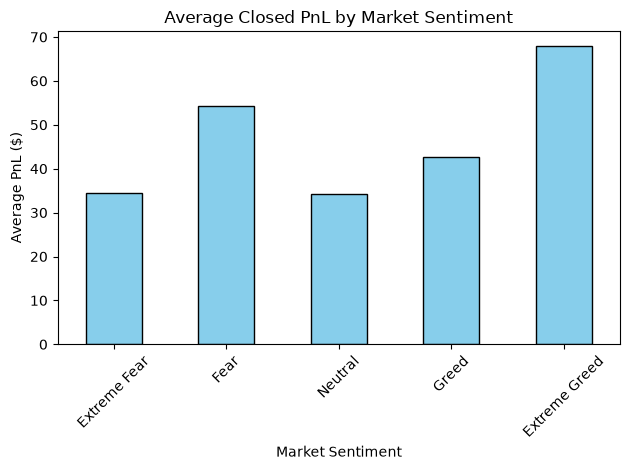

In [25]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().reindex(order)
avg_pnl.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average PnL ($)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Dataset/avg_pnl_chart.png')
plt.show()

### Chart 2: PnL Distribution by Market Sentiment

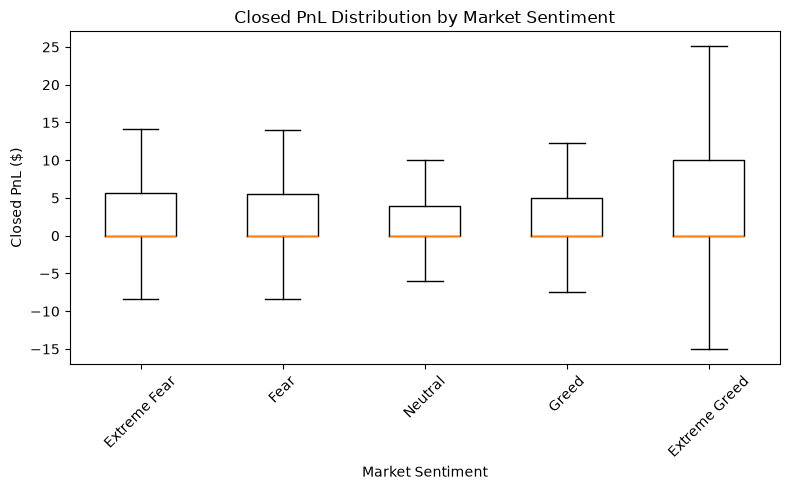

In [26]:
plt.figure(figsize=(8,5))
data_to_plot = [merged[merged['classification']==cat]['Closed PnL'] for cat in order]
plt.boxplot(data_to_plot, showfliers=False)
plt.xticks(ticks=range(1, len(order)+1), labels=order, rotation=45)
plt.title('Closed PnL Distribution by Market Sentiment')
plt.ylabel('Closed PnL ($)')
plt.xlabel('Market Sentiment')
plt.tight_layout()
plt.savefig('Dataset/pnl_boxplot.png')
plt.show()

### Chart 3: Long Trade % by Market Sentiment

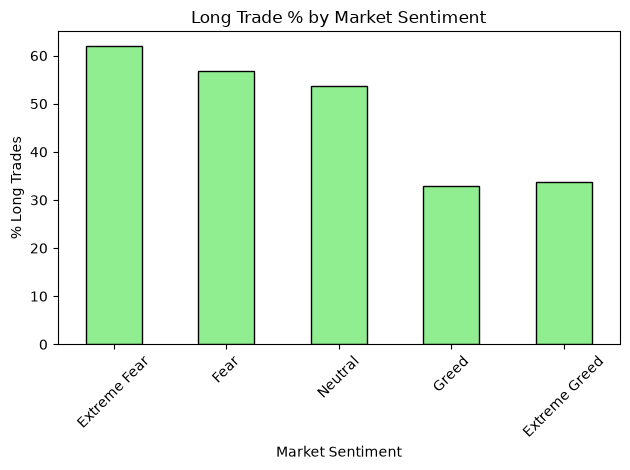

In [27]:
long_ratio = merged.groupby('classification')['Direction'].apply(
    lambda x: (x.str.contains('Long', case=False, na=False)).sum() / len(x) * 100
).reindex(order)

long_ratio.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Long Trade % by Market Sentiment')
plt.ylabel('% Long Trades')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Dataset/long_ratio_chart.png')
plt.show()

## Final Conclusion

**Main finding:** Traders behave like contrarians — going long more during Fear 
(62% in Extreme Fear) and less during Greed (33% in Extreme Greed).

**Performance:** This contrarian behavior pays off — higher win rate and total 
profit during Fear vs Greed. The difference is statistically significant 
(p = 1.30 × 10⁻⁶⁸).

**Risk:** Extreme Greed has the widest range of outcomes (biggest wins and 
losses) — highest risk despite good average returns.

## Strategy Recommendation
- Increase exposure during Fear/Extreme Fear periods
- Reduce position size during Extreme Greed due to higher risk